In [1]:
import os
import mudata as mu
import pertpy as pt
import scanpy as sc
import pandas as pd
import mudata as mu
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

milo = pt.tl.Milo()

from pertpy.tools import Milo


In [2]:
# load annotations
adata = sc.read_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/data/Batch001-Batch007_raw_03_fine_annot.h5ad")

adata.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD4 naive/Tcm                 407516
CD8 naive/Tcm                 175694
CD56_dim CD16+ NK             171221
gdT                           136632
CD4 Tem                        96510
Naive B cell                   74528
Classical monocyte             51309
CD8 Tem                        50185
Tfh                            45002
CD8 GZMK+ naive/Tcm            39689
Treg                           39431
Switched memory B cell         39115
MAIT                           33604
Transitional B cell            20038
CX3CR1_high ncMonocyte         16593
ILC1                           16331
CD56_dim CD16+ KLRC2+ NK       15081
Intermediate monocyte          10877
CD4 cytoT                       8027
Platelet                        7029
Atypical memory B cell          5734
cDC2                            5434
pDC                             4415
Proliferating lymphocyte        2683
iILC2                           2400
DP T                            23

In [3]:
adata

AnnData object with n_obs × n_vars = 1485141 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'

In [3]:
adata.obs["pica_id"].unique()
adata.obs['pica_id'].value_counts().sort_index()

pica_id
PICA0001     3992
PICA0002     3367
PICA0003     3357
PICA0004     3554
PICA0005     4943
            ...  
PICA0164    12172
PICA0166    12216
PICA0168    12590
PICA0169    12506
PICA0173    13800
Name: count, Length: 128, dtype: int64

In [4]:
print(adata)

AnnData object with n_obs × n_vars = 1485141 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'


### load metadata

In [5]:
meta_raw = pd.read_csv("/scratch/user/s4575250/BIOX7014_Thesis/data/PICA-PICAReportOverall_DATA_LABELS_2025-07-25_1224.csv")

In [6]:
# convert Record ID -> PICA format (PICA0001)
meta = meta_raw.copy()
meta["Record ID"] = meta["Record ID"].astype(int)

meta["pica_id"] = meta["Record ID"].apply(lambda x: f"PICA{x:04d}")
meta.set_index("pica_id", inplace=True)

print(meta["Record ID"])

pica_id
PICA0001      1
PICA0002      2
PICA0003      3
PICA0004      4
PICA0005      5
           ... 
PICA0269    269
PICA0270    270
PICA0271    271
PICA0272    272
PICA0273    273
Name: Record ID, Length: 273, dtype: int64


In [7]:
# restrict meta to only those in adata
adata_picas = adata.obs["pica_id"].unique()
meta_sub = meta.loc[meta.index.isin(adata_picas)].copy()

print("Metadata before restricting:", meta.shape[0], "rows")
print("Metadata after restricting:", meta_sub.shape[0], "rows")

Metadata before restricting: 273 rows
Metadata after restricting: 128 rows


In [8]:
# mapping pica id in metadata to pica id in adata
adata.obs["pica_id"] = adata.obs["pica_id"].astype(str)
meta_sub.index = meta_sub.index.astype(str)

for col in meta_sub.columns:
    # build a mapping pica_id -> value
    mapping = meta_sub[col]
    adata.obs[col] = adata.obs["pica_id"].map(mapping)

adata.obs[[ "pica_id", "Record ID" ]].head()  
print("n_obs:", adata.n_obs)
print("obs rows:", adata.obs.shape[0])

n_obs: 1485141
obs rows: 1485141


In [9]:
print(adata.obs.columns)


Index(['status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch',
       'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type',
       'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type',
       'pica_cell_type_01_myeloid', 'pica_cell_type_02_b',
       'pica_cell_type_03_nk_t', 'pica_cell_type_complete',
       'pica_broad_cell_type_complete',
       'pica_broad_cell_type_complete_01_gdT_corrected',
       'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica',
       'Record ID', 'Sex', 'Age (years)', 'Age', 'Event Name',
       'Was baseline blood 

In [10]:
meta_summary = (
    adata.obs[["pica_id", "Child's sex", "Age in years at the time of collection"]]
    .drop_duplicates()
    .sort_values("pica_id")
)
print(meta_summary)

                                                     pica_id Child's sex  \
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0001        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0002        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0003        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0004        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0005        Male   
...                                                      ...         ...   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0164        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0166        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0168        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0169        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0173        Male   

                                                    Age in years at the time of collect

In [11]:
## renaming covariates

adata.obs['Batch'] = adata.obs['sequencing_batch'].map(
        {
            '20240530_WGS_20240530_sc_PICA0001-PICA0007': "Batch01",
            '20240918_WGS_20240924_sc_PICA0008-PICA0032': "Batch02",
            '20241106_WGS_20241106_sc_PICA0033-PICA0069': "Batch03",
            '20250114_WGS_20241218_sc_PICA0071-PICA0097': "Batch04",
            '20250324_WGS_20250324_sc_PICA0098-PICA0118': "Batch05",
            '20250612_WGS_20250612_sc_PICA0119-PICA0146': "Batch06",
            '20250814_WGS_20250814_sc_PICA0147-PICA0173': "Batch07"
        }
    )

adata.obs = adata.obs.rename(columns={
    "Age (years)": "Age_years"
})

In [12]:
meta_summary_renamed = (
    adata.obs[["Batch","pica_id", "Sex", "Age_years"]]
    .drop_duplicates()
    .sort_values("pica_id")
)
print(meta_summary_renamed)

                                                      Batch   pica_id   Sex  \
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  Batch01  PICA0001  Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  Batch01  PICA0002  Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  Batch01  PICA0003  Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  Batch01  PICA0004  Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  Batch01  PICA0005  Male   
...                                                     ...       ...   ...   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  Batch07  PICA0164  Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  Batch07  PICA0166  Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  Batch07  PICA0168  Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  Batch07  PICA0169  Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  Batch07  PICA0173  Male   

                                                   

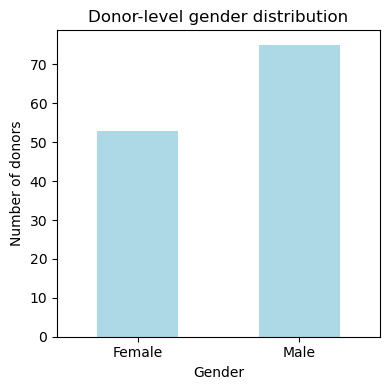

In [13]:
gender_meta_df = adata.obs[["pica_id", "Sex"]].drop_duplicates()

gender_meta_df["Sex"].value_counts().sort_index().plot(
    kind="bar", color="lightblue", figsize=(4,4)
)
plt.title("Donor-level gender distribution")
plt.xlabel("Gender")
plt.ylabel("Number of donors")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

/scratch/temp/23302424/ipykernel_2826118/677765789.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=meta_df, x="Sex", y="Age_years", palette="Set2")


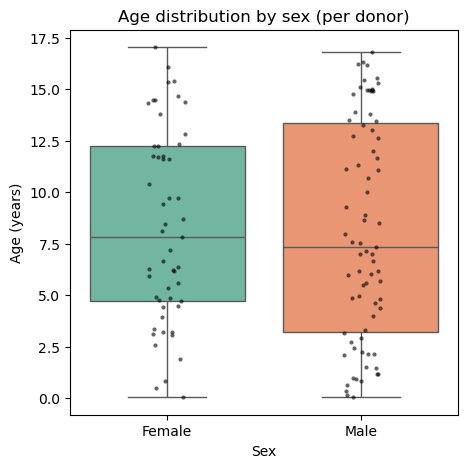

In [14]:
meta_df = adata.obs[['pica_id', "Sex", "Age_years"]].drop_duplicates()

plt.figure(figsize=(5,5))
sns.boxplot(data=meta_df, x="Sex", y="Age_years", palette="Set2")
sns.stripplot(data=meta_df, x="Sex", y="Age_years", color="k", size=3, alpha=0.6)
plt.title("Age distribution by sex (per donor)")
plt.ylabel("Age (years)")
plt.xlabel("Sex")
plt.show()

In [15]:
# clean types for downstream analysis
adata.obs = adata.obs.applymap(
    lambda x: str(x) if not isinstance(x, (int, float, str)) else x
)

/scratch/temp/23302424/ipykernel_2826118/3091035492.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adata.obs = adata.obs.applymap(


In [16]:
adata.obs.groupby("pica_id")["Age_years"].unique()

pica_id
PICA0001     [2.09]
PICA0002    [15.09]
PICA0003     [0.83]
PICA0004     [1.46]
PICA0005      [9.3]
             ...   
PICA0164     [2.15]
PICA0166     [0.62]
PICA0168     [16.2]
PICA0169     [2.72]
PICA0173    [15.31]
Name: Age_years, Length: 128, dtype: object

In [17]:
adata.obs.groupby("pica_id")["Age"].unique()

pica_id
PICA0001     [2]
PICA0002    [15]
PICA0003     [0]
PICA0004     [1]
PICA0005     [9]
            ... 
PICA0164     [2]
PICA0166     [0]
PICA0168    [16]
PICA0169     [2]
PICA0173    [15]
Name: Age, Length: 128, dtype: object

In [18]:
# Define bins and labels
bins = [0, 3, 6, 10, 14, 18]
labels = ["0–3", "4–6", "7–10", "11–14", "15–18"]

# Create new column for grouped ages
adata.obs["Age_group"] = pd.cut(
    adata.obs["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

In [19]:
adata.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      336749
4–6      352468
7–10     240674
11–14    416019
15–18    139231
Name: count, dtype: int64

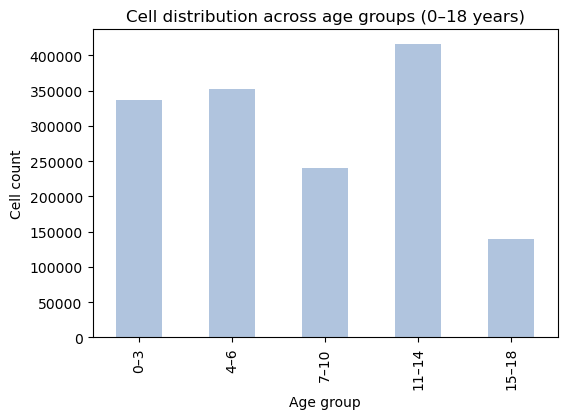

In [20]:
adata.obs["Age_group"].value_counts().sort_index().plot(
    kind="bar", figsize=(6,4), color="lightsteelblue"
)
plt.title("Cell distribution across age groups (0–18 years)")
plt.xlabel("Age group")
plt.ylabel("Cell count")
plt.show()

In [21]:
adata

AnnData object with n_obs × n_vars = 1485141 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in

### compute neighbourhood

### Prepare for Milo analysis

In [23]:
adata.obs["Batch"] = adata.obs["Batch"].astype("category")
adata.obs["Age_years"] = adata.obs["Age_years"].astype("float")
adata.obs["Sex"] = adata.obs["Sex"].astype("category")
adata.obs["Age"] = adata.obs["Age"].astype("int")

In [24]:
adata.obs["Sex"].value_counts()


Sex
Male      840743
Female    644398
Name: count, dtype: int64

In [25]:
adata.obs["Age_years"].value_counts().sort_index()

Age_years
0.05     11486
0.07     11465
0.14      4094
0.35     12847
0.48     10796
         ...  
16.16    12161
16.20    12590
16.29    11291
16.78    10877
17.03    14098
Name: count, Length: 122, dtype: int64

In [26]:
adata.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      336749
4–6      352468
7–10     240674
11–14    416019
15–18    139231
Name: count, dtype: int64

In [27]:
adata.obs["Age"].value_counts().sort_index()

Age
0     104303
1      53227
2      87995
3      91224
4     151808
5      80498
6     120162
7      92155
8      69967
9      43193
10     35359
11    121864
12     71899
13     91584
14    130672
15     68505
16     56628
17     14098
Name: count, dtype: int64

In [28]:
adata.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")

/scratch/temp/23302424/ipykernel_2826118/2240604081.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")


,Age_years,Sex,n_donors
0,0.05,Female,0
1,0.05,Male,1
2,0.07,Female,1
3,0.07,Male,0
4,0.14,Female,0
...,...,...,...
239,16.29,Male,1
240,16.78,Female,0
241,16.78,Male,1
242,17.03,Female,1


In [29]:
adata.obs.drop_duplicates(subset="pica_id").groupby(["Age", "Sex"]).size().reset_index(name="n_donors")

/scratch/temp/23302424/ipykernel_2826118/399094250.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.drop_duplicates(subset="pica_id").groupby(["Age", "Sex"]).size().reset_index(name="n_donors")


,Age,Sex,n_donors
0,0,Female,3
1,0,Male,7
2,1,Female,1
3,1,Male,4
4,2,Female,1
5,2,Male,7
6,3,Female,6
7,3,Male,2
8,4,Female,6
9,4,Male,6


In [30]:
milo = pt.tl.Milo()
mdata = milo.load(adata)

In [31]:
mdata

MuData object with n_obs × n_vars = 1485141 × 38606
  2 modalities
    rna:	1485141 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
    milo:	0 x 0

In [32]:
# Build KNN graph
sc.pp.neighbors(mdata["rna"], use_rep="X_scVI", n_neighbors=75)

ValueError: Did not find X_scVI in `.obsm.keys()`. You need to compute it first.

In [ ]:
# Build neighbourhood graph
milo.make_nhoods(mdata["rna"], prop=0.1)

In [ ]:
mdata["rna"].obsm["nhoods"]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 2619640 stored elements and shape (187173, 9851)>

In [ ]:
mdata["rna"][mdata["rna"].obs["nhood_ixs_refined"] != 0].obs[["nhood_ixs_refined", "nhood_kth_distance"]]

,nhood_ixs_refined,nhood_kth_distance
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACGCGAGCACTCAA,1,3.457598
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAAGCGAGTATCCTGC,1,3.667299
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAAGGAACAAAACGAT,1,3.363439
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AACAGCCTCGCATGGT,1,3.538970
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAGGCACCACATGAAG,1,3.390574
...,...,...
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTTCAGTCAATGCGCC,1,3.708672
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTTGCCACACTCGGGT,1,4.008997
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTTGCCACAGCACACC,1,3.595360
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTTGCGTAGGTCTATG,1,4.445430


Text(0, 0.5, '# nhoods')

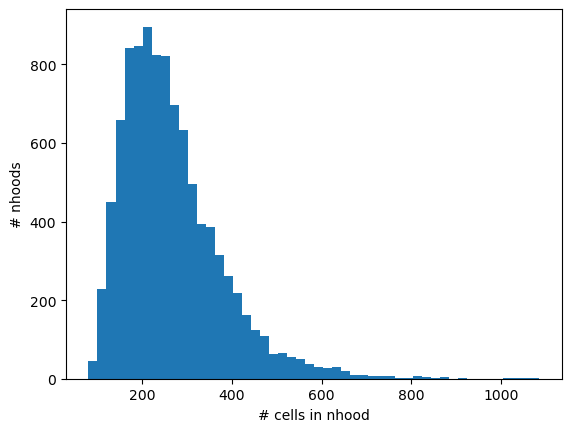

In [ ]:
nhood_size = np.array(mdata["rna"].obsm["nhoods"].sum(0)).ravel()
plt.hist(nhood_size, bins=50)
plt.xlabel("# cells in nhood")
plt.ylabel("# nhoods")

In [ ]:
# count cells in neighbourhood
mdata= milo.count_nhoods(mdata, sample_col="pica_id") 

In [ ]:
mdata

MuData object with n_obs × n_vars = 187173 × 38606
  2 modalities
    rna:	187173 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group', '_scvi_batch', '_scvi_labels', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'umap', 'pool_id_colors', 'Sex_colors', 'nhood_neighbors_key'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 9851
      var:	'index_cell', 'kth_distance'
      uns:	'sample_col'

In [ ]:
mdata["milo"]

AnnData object with n_obs × n_vars = 128 × 9851
    var: 'index_cell', 'kth_distance'
    uns: 'sample_col'

In [ ]:
donor_meta = (
    mdata.obs[["pica_id", "Age_years","Age", "Sex", "Batch", "Age_group"]]
    .drop_duplicates("pica_id")
    .set_index("pica_id")
)
donor_meta = donor_meta.loc[mdata["milo"].obs_names]

In [ ]:
mdata["milo"].obs["Age_years"] = donor_meta["Age_years"].values
mdata["milo"].obs["Sex"] = donor_meta["Sex"].values
mdata["milo"].obs["Batch"] = donor_meta["Batch"].values
mdata["milo"].obs["Age"] = donor_meta["Age"].values
mdata["milo"].obs["Age_group"] = donor_meta["Age_group"].values


In [33]:
mdata["milo"].obs["Sex"] = mdata["milo"].obs["Sex"].astype("category")
mdata["milo"].obs["Age_years"] = mdata["milo"].obs["Age_years"].astype("float")
mdata["milo"].obs["Batch"] = mdata["milo"].obs["Batch"].astype("category")
mdata["milo"].obs["Age"] = mdata["milo"].obs["Age"].astype("int")
mdata["milo"].obs["Age_group"] = mdata["milo"].obs["Age_group"].astype("category")


KeyError: 'Sex'

In [34]:
donor_meta

NameError: name 'donor_meta' is not defined

In [35]:
mdata["milo"]

AnnData object with n_obs × n_vars = 0 × 0

In [36]:
mdata.write_h5mu(
    "/scratch/user/s4575250/BIOX7014_Thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_milo_nhoods_built.h5mu"
)

In [37]:
mdata["milo"].obs["Age_years"].value_counts().sort_index()

KeyError: 'Age_years'

In [ ]:
mdata["milo"].obs["Sex"].value_counts().sort_index()

Sex
Female    53
Male      75
Name: count, dtype: int64

In [ ]:
mdata["milo"].obs["Age_group"].value_counts().sort_index()

Age_group
0–3      31
4–6      29
7–10     21
11–14    34
15–18    13
Name: count, dtype: int64

In [ ]:
mdata["milo"]

AnnData object with n_obs × n_vars = 128 × 9851
    obs: 'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'
    var: 'index_cell', 'kth_distance'
    uns: 'sample_col'

In [ ]:
mdata

MuData object with n_obs × n_vars = 187301 × 48457
  2 modalities
    rna:	187173 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group', '_scvi_batch', '_scvi_labels', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'umap', 'pool_id_colors', 'Sex_colors', 'nhood_neighbors_key'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 9851
      obs:	'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'
      var:	'index_cell', 'kth_di